### Инициализация проекта

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from ucimlrepo import fetch_ucirepo 

In [21]:
wine_quality = fetch_ucirepo(id=186) 
  
X = wine_quality.data.features 
y = wine_quality.data.targets
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [22]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


In [23]:
data = pd.concat([X, y], axis=1)
data

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


### Исследование исходных данных

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [25]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [26]:
data.head(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


<font size=4>
Датасет содержит следующие поля:

- `fixed_acidity` — фиксированная кислотность
- `volatile_acidity` — летучая кислотность
- `citric_acid` — лимонная кислота
- `residual_sugar` — остаточный сахар
- `chlorides` — хлориды
- `free_sulfur_dioxide` — свободный диоксид серы
- `total_sulfur_dioxide` — общий диоксид серы
- `density` — плотность
- `pH` — pH
- `sulphates` — сульфаты
- `alcohol` — спирт
- `quality` — качество (оценка от 0 до 10)
</font>

Заключение по исходным данным:
- поля "free_sulfur_dioxide", "total_sulfur_dioxide" следует перевести из типа float в тип int

### Заполнение пропусков

In [27]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

fixed_acidity           0.0
volatile_acidity        0.0
citric_acid             0.0
residual_sugar          0.0
chlorides               0.0
free_sulfur_dioxide     0.0
total_sulfur_dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

### Исправление типов данных

In [28]:
data['free_sulfur_dioxide'] = data['free_sulfur_dioxide'].astype(int)
data['total_sulfur_dioxide'] = data['total_sulfur_dioxide'].astype(int)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   int64  
 6   total_sulfur_dioxide  6497 non-null   int64  
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 609.2 KB


### **Проверка "очищенных" данных**

In [30]:
data.head(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13,40,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15,59,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15,21,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9,18,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17,102,0.9978,3.35,0.80,10.5,5


In [31]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.520856,115.742343,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.743162,56.518612,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# EDA

### Что влияет на вкус

In [32]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5


In [33]:
wine_quality = data.groupby(['quality']).mean()
wine_quality

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,7.853333,0.517000,0.281000,5.140000,0.077033,39.166667,122.000000,0.995744,3.257667,0.506333,10.215000
4,7.288889,0.457963,0.272315,4.153704,0.060056,20.629630,103.430556,0.994833,3.231620,0.505648,10.180093
5,7.326801,0.389614,0.307722,5.804116,0.064666,30.234331,120.837699,0.995849,3.212189,0.526403,9.837783
6,7.177257,0.313863,0.323583,5.549753,0.054157,31.161142,115.409027,0.994558,3.217726,0.532549,10.587553
7,7.128962,0.288800,0.334764,4.731696,0.045272,30.414272,108.496756,0.993126,3.228072,0.547025,11.386006
8,6.835233,0.291010,0.332539,5.382902,0.041124,34.533679,117.502591,0.992514,3.223212,0.512487,11.678756
9,7.420000,0.298000,0.386000,4.120000,0.027400,33.400000,116.000000,0.991460,3.308000,0.466000,12.180000


Несколько говорящих о хорошем вкусе параметров, которые можно сразу выделить:
- Низкая летучая кислотность
- Высокое сожержание лимонной кислоты
- Низкое содержание хлоридов
- Низкое содержание сульфатов
- Высокая крепость

Попробуем ещё подкрепить это:

In [34]:
volatile_acidity = data.groupby(['quality']).quantile(0.5)
volatile_acidity

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,7.45,0.415,0.33,3.15,0.0550,17.0,102.5,0.995900,3.245,0.505,10.15
4,7.00,0.380,0.26,2.20,0.0505,15.0,102.0,0.994995,3.220,0.485,10.00
5,7.10,0.330,0.30,3.00,0.0530,27.0,127.0,0.996100,3.190,0.500,9.60
6,6.90,0.270,0.31,3.10,0.0460,29.0,117.0,0.994700,3.210,0.510,10.50
7,6.90,0.270,0.32,2.80,0.0390,30.0,114.0,0.992400,3.220,0.520,11.40
8,6.80,0.280,0.32,4.10,0.0370,34.0,118.0,0.991890,3.230,0.480,12.00
9,7.10,0.270,0.36,2.20,0.0310,28.0,119.0,0.990300,3.280,0.460,12.50


Результаты аналогичны

Но есть отличия в показания у свободного диоксида серы "free_sulfur_dioxide"

In [35]:
volatile_acidity = (data.groupby(['quality']).quantile(0.25)['free_sulfur_dioxide'] + data.groupby(['quality']).quantile(0.75)['free_sulfur_dioxide']) / 2
volatile_acidity

quality
3    21.250
4    17.625
5    29.500
6    30.000
7    30.000
8    33.500
9    29.000
Name: free_sulfur_dioxide, dtype: float64

Так и есть, чем выше показатель, тем выше оценивается вкус

## Анализ по графикам

### Фиксированная кислотность "fixed_acidity"

Text(0.5, 1.0, 'fixed_acidity')

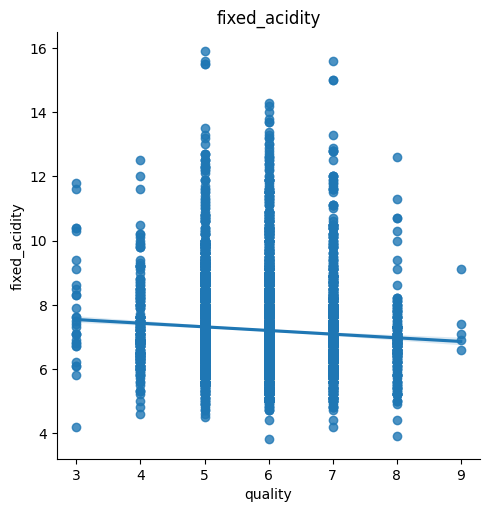

In [36]:
sns.lmplot(x="quality", y="fixed_acidity", data=data)
plt.title('fixed_acidity')

### Летучая кислотность "volatile_acidity"

Text(0.5, 1.0, 'volatile_acidity')

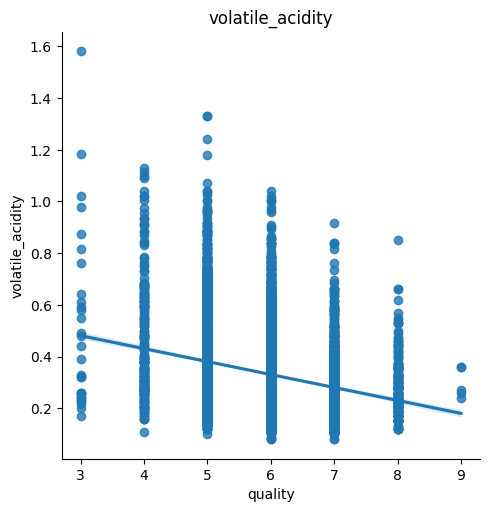

In [37]:
sns.lmplot(x="quality", y="volatile_acidity", data=data)
plt.title('volatile_acidity')

### Лимонная кислота "citric_acid"

Text(0.5, 1.0, 'citric_acid')

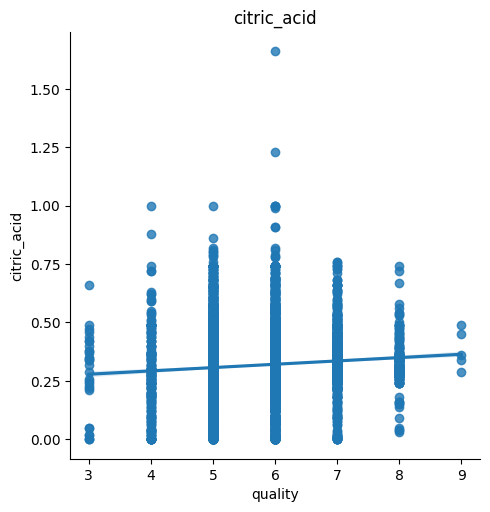

In [38]:
sns.lmplot(x="quality", y="citric_acid", data=data)
plt.title('citric_acid')

### Остаточный сахар "residual_sugar"

Text(0.5, 1.0, 'residual_sugar')

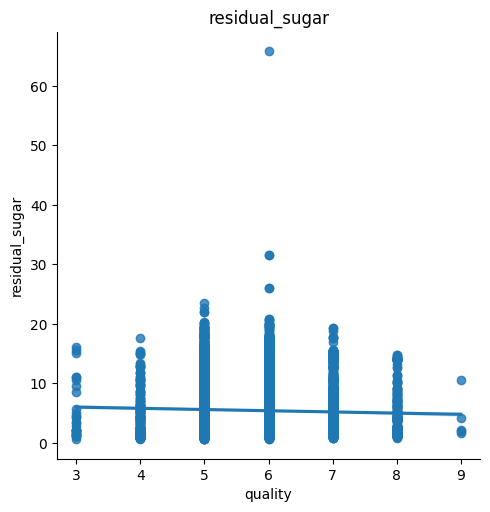

In [39]:
sns.lmplot(x="quality", y="residual_sugar", data=data)
plt.title('residual_sugar')

### Хлориды "chlorides"

Text(0.5, 1.0, 'chlorides')

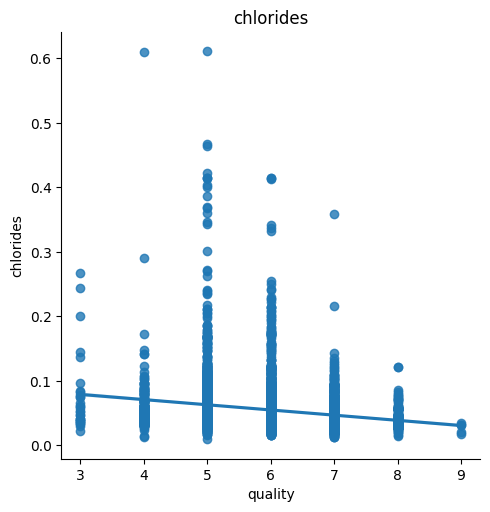

In [40]:
sns.lmplot(x="quality", y="chlorides", data=data)
plt.title('chlorides')

### Свободный диоксид серы "free_sulfur_dioxide"

Text(0.5, 1.0, 'free_sulfur_dioxide')

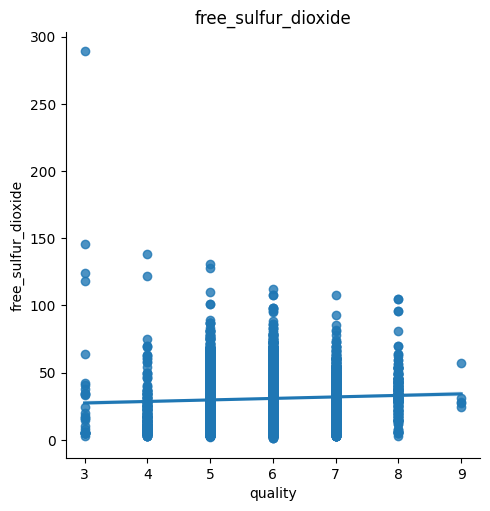

In [41]:
sns.lmplot(x="quality", y="free_sulfur_dioxide", data=data)
plt.title('free_sulfur_dioxide')

### Общий диоксид серы "total_sulfudensityr_dioxide"

Text(0.5, 1.0, 'total_sulfur_dioxide')

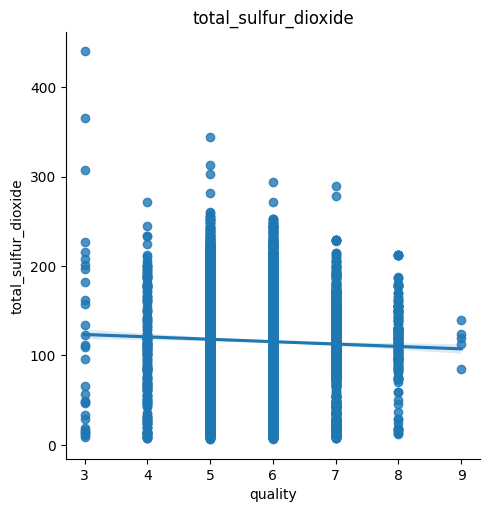

In [43]:
sns.lmplot(x="quality", y="total_sulfur_dioxide", data=data)
plt.title('total_sulfur_dioxide')

### Плотность "density"

Text(0.5, 1.0, 'density')

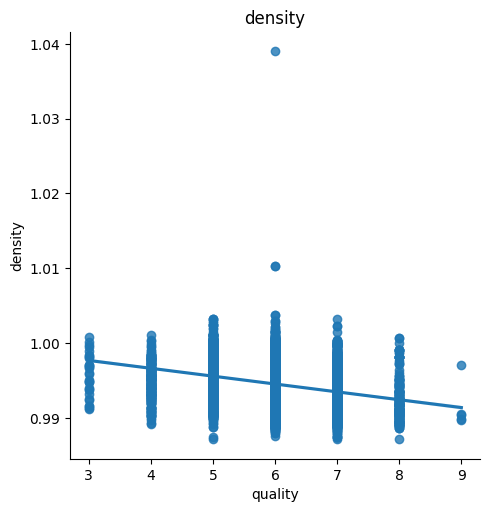

In [44]:
sns.lmplot(x="quality", y="density", data=data)
plt.title('density')

### pH "pH"

Text(0.5, 1.0, 'pH')

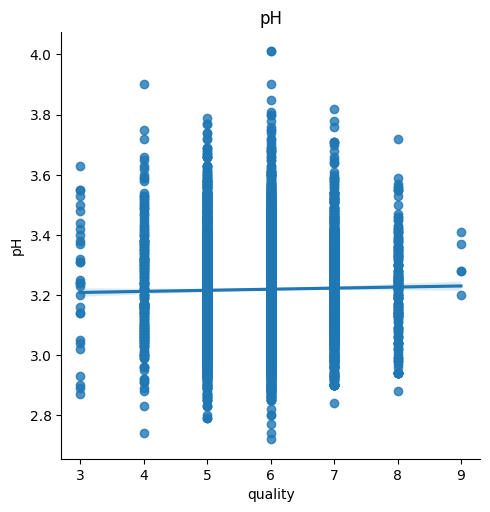

In [45]:
sns.lmplot(x="quality", y="pH", data=data)
plt.title('pH')

### Сульфаты "sulphates"

Text(0.5, 1.0, 'sulphates')

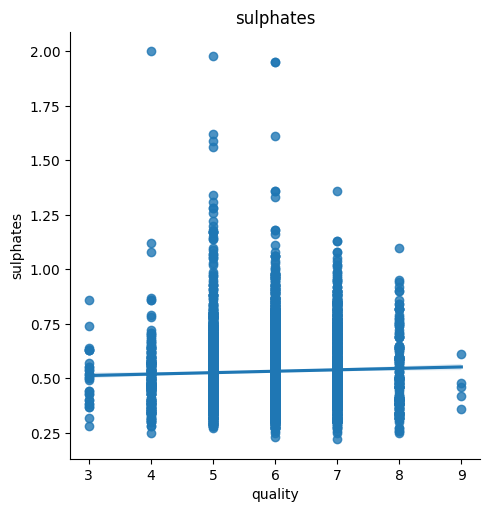

In [46]:
sns.lmplot(x="quality", y="sulphates", data=data)
plt.title('sulphates')

### Спирт "alcohol"

Text(0.5, 1.0, 'alcohol')

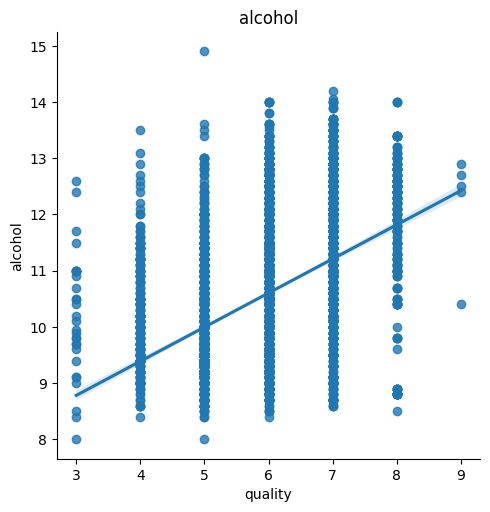

In [47]:
sns.lmplot(x="quality", y="alcohol", data=data)
plt.title('alcohol')